### Pipeline

This script takes a single 2D TIFF frame, extracts a region of interest (ROI), removes a smooth background, and then uses juwavelet to identify and visualize the main gravity‐wave packets.

Pipeline:

1. Load the full TIFF as a 2D float32 array and compute the global mean and sigma.
2. Build a full-frame preview:
   - Mask pixels outside mean ± (SIGMA_FACTOR · σ).
   - Display the masked image with a fixed color range and draw the ROI rectangle.
3. Extract the ROI using X_SLICE and Y_SLICE.
4. Apply the same global mean ± σ range filter inside the ROI (optional), and fill “invalid” pixels (outside the range) so the ROI remains a full rectangle for the CWT.
5. Remove a smooth background from the ROI:
   - Fit and subtract a 2D plane (optional).
   - Extract and subtract the first Fourier components in x and y.
   - Define the “remaining” field = original − background.
6. Apply a Hanning edge taper to the remaining field (optional), then optionally despike it using a local median / MAD filter (DESPIKE_SIZE, DESPIKE_K).
7. Make a 4-panel figure showing:
   - Original (median-subtracted).
   - Background (plane + first Fourier).
   - Remaining = original − background.
   - Remaining with edge taper (and spikes removed).
8. Preprocess the tapered, despiked field for CWT:
   - Median-center and standardize (optional).
   - Apply a small Gaussian blur (optional).
9. Run 2D continuous wavelet transform with juwavelet.decompose2d using the specified S0, DJ, JS, JT, DX, DY, ASPECT.
10. Identify wave clusters in wavelet space with utils.identify_cluster2d (CLUSTER_MIN_AMP, CLUSTER_THR).
11. Plot:
    - A decomposition overview (utils.plot_decomposition2d).
    - A FOV wavelet spectrum (orientation vs wavelength) via plot_utils.plot_fov_wavelet_spectrum.
12. For the 9 strongest clusters:
    - Reconstruct each cluster back into physical space.
    - Plot 9 standalone cluster fields (median-centered).
    - Plot 9 overlays: each cluster on top of the tapered, despiked background field.

Outputs: one full-frame preview, one 4-panel background figure, a CWT summary figure, a polar FOV spectrum, 9 standalone cluster plots, and 9 cluster-on-background overlays.


[Full] mean: 12564.34
[Full] sigma: 3491.38
[Full] Clip range: [10818.66, 14310.03] = mean ± 0.50·sigma
[Full] Count: 81920
[Full] Min/max after clip: 10818.66 / 14310.03
[Full] Percentiles 5/50/95 (clipped): 10818.66 / 12654.00 / 14310.03


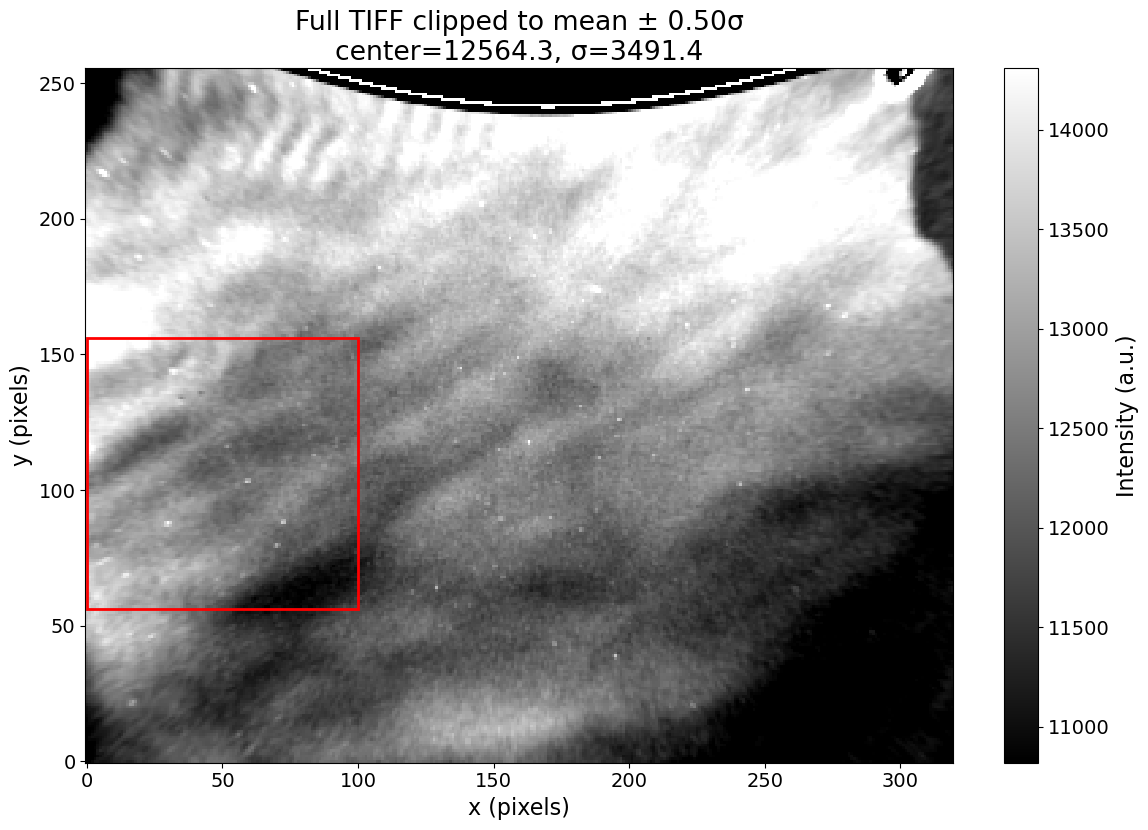

[ROI] shape: (100, 100)
[ROI] Count: 10000
[ROI] Min/max after clip: 10818.66 / 14310.03
[ROI] Percentiles 5/50/95 (clipped): 11241.80 / 12579.00 / 13815.05


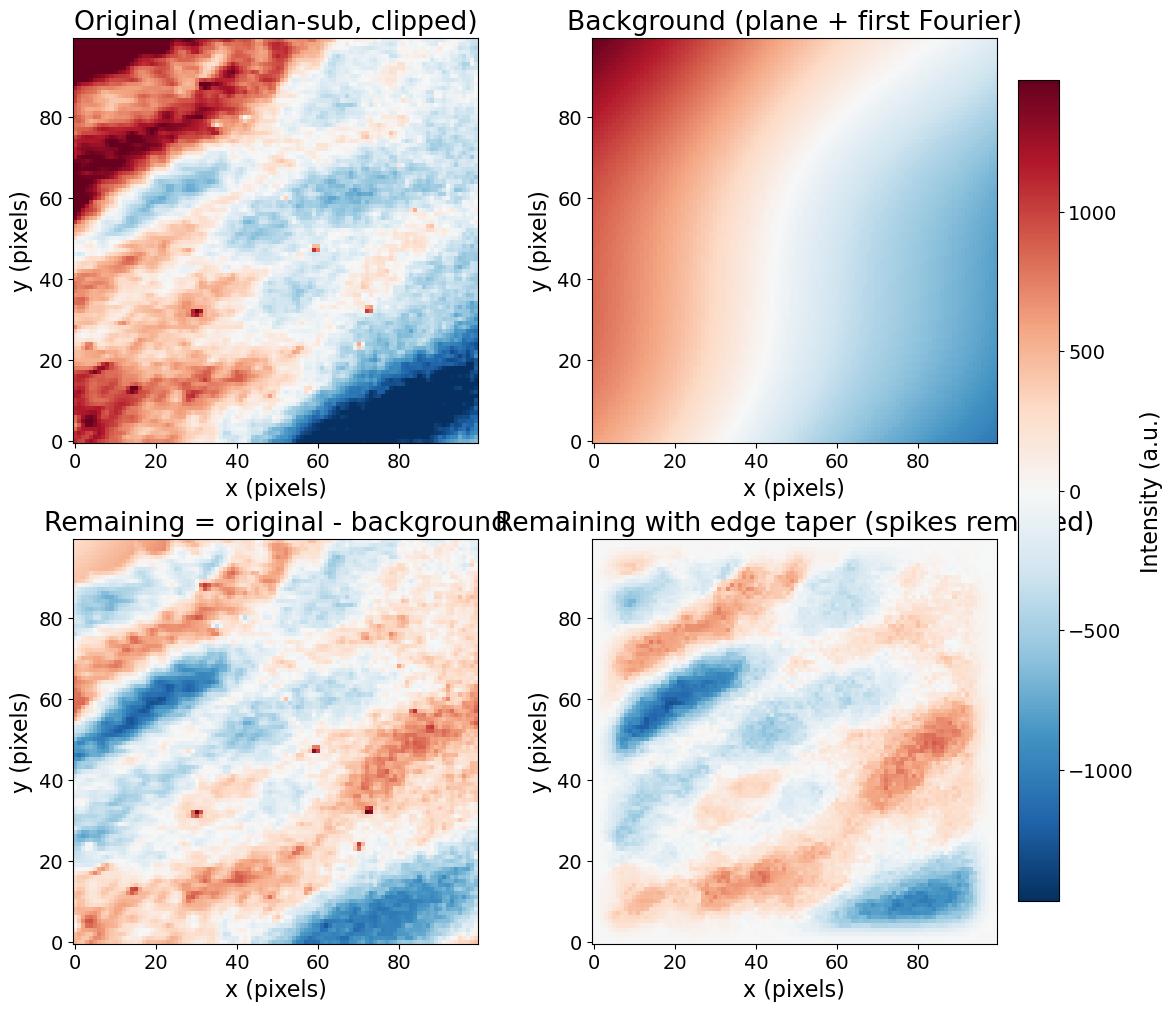

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.7416955771547348 idx= (np.int64(14), np.int64(6), np.int64(26), np.int64(31))
selected elements: 223320
------------
cluster= 1
amplitude= 0.3701365525475396 idx= (np.int64(15), np.int64(8), np.int64(61), np.int64(86))
selected elements: 11558
------------
cluster= 2
amplitude= 0.32614233910805845 idx= (np.int64(11), np.int64(4), np.int64(10), np.int64(43))
selected elements: 3477
------------
cluster= 3
amplitude= 0.31237424426915655 idx= (np.int64(9), np.int64(6), np.int64(21), np.int64(49))
selected elements: 2070
------------
cluster= 4
amplitude= 0.29128482325682437 idx= (np.int64(10), np.int64(7), np.int64(25), np.int64(52))
selected elements: 1279
------------
cluster= 5
amplitude= 0.29051720932910247 idx= (np.int64(25), np.int64(6), np.int64(53), np.int64(65))
selected elements: 82192
------------
cluster= 6
amplitude= 0.2861953636604494 idx= (np.int64(11), np.int64(8), np.int64(71), np.int64(92))
selected elements: 5738
------------
cluster

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 60.55it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


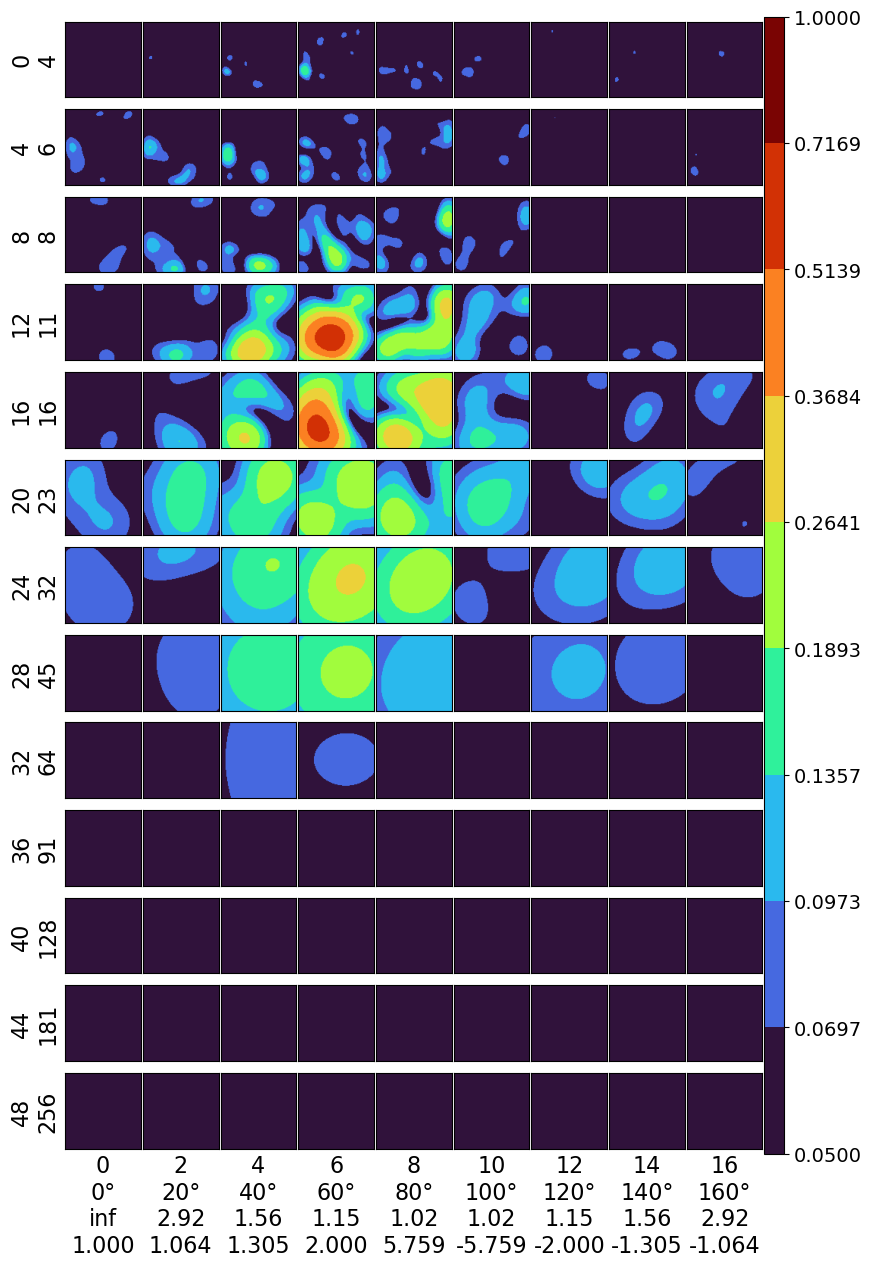

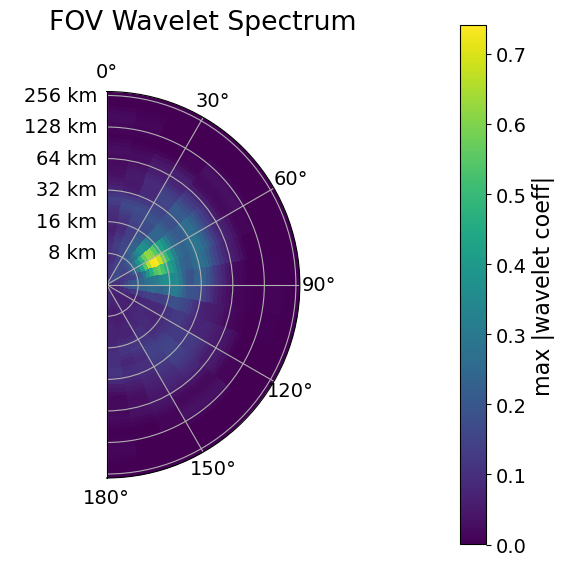

[Clusters-only] Cluster 0: amp=0.742, lamx=26.91, lamy=15.54, lam=13.45
[Clusters-only] Cluster 1: amp=0.370, lamx=84.49, lamy=14.90, lam=14.67
[Clusters-only] Cluster 2: amp=0.326, lamx=13.54, lamy=16.14, lam=10.37
[Clusters-only] Cluster 3: amp=0.312, lamx=17.45, lamy=10.07, lam=8.72
[Clusters-only] Cluster 4: amp=0.291, lamx=27.82, lamy=10.12, lam=9.51
[Clusters-only] Cluster 5: amp=0.291, lamx=69.79, lamy=40.29, lam=34.90
[Clusters-only] Cluster 6: amp=0.286, lamx=59.75, lamy=10.53, lam=10.37
[Clusters-only] Cluster 7: amp=0.279, lamx=93.56, lamy=34.05, lam=32.00
[Clusters-only] Cluster 8: amp=0.258, lamx=45.25, lamy=26.13, lam=22.63


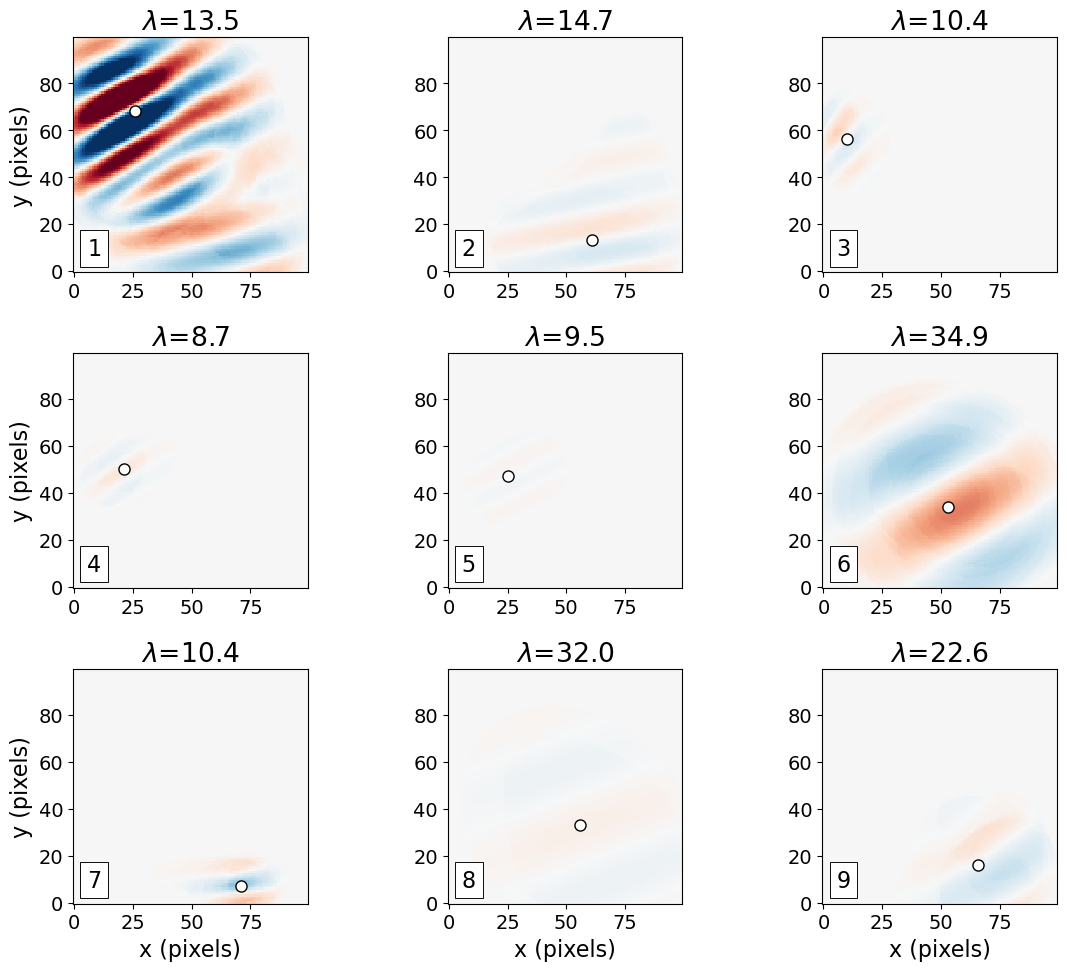

[Overlay] Cluster 0: amp=0.742, lamx=26.91, lamy=15.54, lam=13.45
[Overlay] Cluster 1: amp=0.370, lamx=84.49, lamy=14.90, lam=14.67
[Overlay] Cluster 2: amp=0.326, lamx=13.54, lamy=16.14, lam=10.37
[Overlay] Cluster 3: amp=0.312, lamx=17.45, lamy=10.07, lam=8.72
[Overlay] Cluster 4: amp=0.291, lamx=27.82, lamy=10.12, lam=9.51
[Overlay] Cluster 5: amp=0.291, lamx=69.79, lamy=40.29, lam=34.90
[Overlay] Cluster 6: amp=0.286, lamx=59.75, lamy=10.53, lam=10.37
[Overlay] Cluster 7: amp=0.279, lamx=93.56, lamy=34.05, lam=32.00
[Overlay] Cluster 8: amp=0.258, lamx=45.25, lamy=26.13, lam=22.63


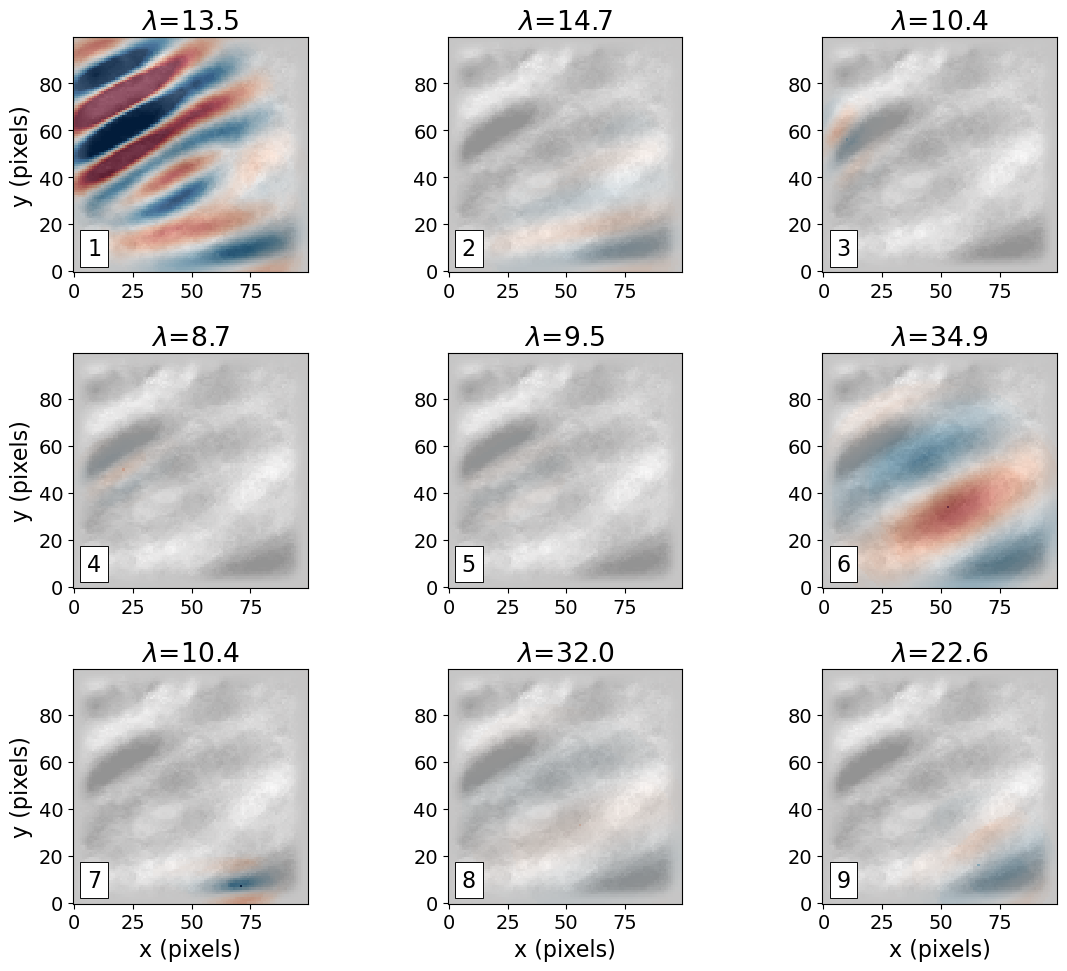

In [5]:
# Full TIFF -> ROI -> background removal -> wavelet clusters
#
# Produces:
#   1) Full TIFF preview (mean ± 0.5 sigma) with ROI rectangle
#   2) 4-panel background figure:
#        - original (median-sub)
#        - background (plane + first Fourier)
#        - remaining
#        - remaining with edge taper, spikes removed (if enabled)
#   3) Wavelet decomposition summary (utils.plot_decomposition2d)
#   4) FOV wavelet spectrum (orientation vs wavelength)
#   5) 9 standalone wavelet clusters (reconstructed fields)
#   6) 9 overlay clusters on top of the tapered remaining field (spikes removed)

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713\BandOH_caun0312.tif"

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(0, 100) #slice(12, 308)
Y_SLICE: Optional[slice] = slice(100, 200) #slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Main pipeline
# --------------------------
def run_pipeline():
    # 1) Load full TIFF
    full = load_tiff(TIFF_PATH)
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # 2) Compute mean/std once on the full image, use ±0.5σ everywhere
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Clip range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Full-image preview with that same range, and ROI rectangle
    preview = full.astype(float)
    disp_prev = np.clip(preview, lo, hi)

    vals_full = disp_prev.ravel()
    if vals_full.size > 0:
        print(f"[Full] Count: {vals_full.size}")
        print(f"[Full] Min/max after clip: {np.nanmin(vals_full):.2f} / {np.nanmax(vals_full):.2f}")
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")
    else:
        print("[Full] Warning: no pixels?")

    # Flip y for display
    y_full_flip = y_full[::-1]

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full,
        y_full_flip,
        disp_prev,
        shading="auto",
        cmap="gray",
        vmin=lo,
        vmax=hi,
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")
    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_title(f"Full TIFF clipped to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}")
    ax_prev.set_aspect("equal", adjustable="box")

    # ROI rectangle in full-image coordinates
    ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
    xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

    x0 = 0 if xsl_full.start is None else xsl_full.start
    x1 = nx_full if xsl_full.stop is None else xsl_full.stop
    y0 = 0 if ysl_full.start is None else ysl_full.start
    y1 = ny_full if ysl_full.stop is None else ysl_full.stop

    # Map to flipped-y display coords: [y0, y1) -> [ny_full - y1, ny_full - y0)
    y0_disp = ny_full - y1
    y1_disp = ny_full - y0

    rect = patches.Rectangle(
        (x0, y0_disp),
        x1 - x0,
        y1_disp - y0_disp,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax_prev.add_patch(rect)

    plt.tight_layout()
    plt.show(fig_prev)

    # 4) Clip to ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flip y for display

    print(f"[ROI] shape: {raw.shape}")

    # 5) Clip ROI values to [lo, hi]
    proc0 = np.clip(raw, lo, hi)

    vals_roi = proc0.ravel()
    if vals_roi.size > 0:
        print(f"[ROI] Count: {vals_roi.size}")
        print(f"[ROI] Min/max after clip: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
        p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
        print(f"[ROI] Percentiles 5/50/95 (clipped): {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
    else:
        print("[ROI] Warning: no pixels?")

    # 6) Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 7) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Remove spikes AFTER tapering (optional)
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 8) 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    imgs_bg = [
        (orig_c, "Original (median-sub, clipped)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, f"Remaining with edge taper (spikes removed)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")

    cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                              fraction=0.04, pad=0.02)
    cbar_bg.set_label("Intensity (a.u.)")

    plt.show(fig_bg)

    # 9) Preprocess for CWT only (standardize + blur) on tapered + de-spiked field
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 10) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # 11) Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                            cmap=cmap_cwt, norm=norm_cwt)
    plt.show(fig_cwt)

    # 12) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # --------------------------
    # Figure 1: 9 standalone clusters
    # --------------------------
    fig1, axs1 = plt.subplots(3, 3, figsize=(12, 10))
    axes1_flat = axs1.flatten()

    opts_img_cluster = {"cmap": "RdBu_r", "vmin": -0.8, "vmax": 0.8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat, biggest):
            # Reconstruct cluster
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]          # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")
            
            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )
            
            print(
                f"[Clusters-only] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes1_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs1[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs1[:, 0]:
        ax.set_ylabel("y (pixels)")

    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes1_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # --------------------------
    # Figure 2: 9 overlays (cluster on tapered field)
    # --------------------------
    fig2, axs2 = plt.subplots(3, 3, figsize=(12, 10))
    axes2_flat = axs2.flatten()

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        cl_vmin, cl_vmax = -0.6, 0.6

        for ax, kcl in zip(axes2_flat, biggest):
            # Background: tapered remaining field (centered, spikes removed), grayscale
            ax.pcolormesh(
                x1d,
                y1d,
                bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            # Reconstruct cluster again
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d,
                y1d,
                rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(rf"$\lambda$={_fmt(lam)}")
            ax.set_aspect("equal", adjustable="box")

            print(
                f"[Overlay] Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # Hide unused axes
        for ax in axes2_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    for ax in axs2[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs2[:, 0]:
        ax.set_ylabel("y (pixels)")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


### Animation

Loaded 11 frames, shape = (11, 256, 320)
center: 12476.44, sigma: 3468.40
use range: [10742.24, 14210.64]


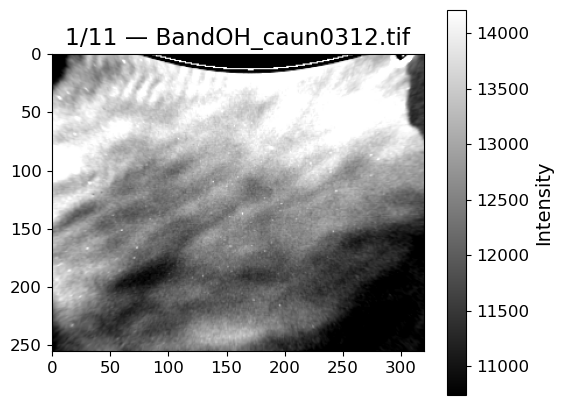

In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------
# User settings
# --------------------
FOLDER = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713"
FACTOR = 0.5  # center ± FACTOR * sigma range

# Load all TIFFs into memory
files = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files:
    raise FileNotFoundError("No TIFFs found in folder.")

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)   # shape: (N, ny, nx)

print(f"Loaded {len(files)} frames, shape = {data.shape}")

# Compute global stats for display
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"center: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot movie animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

title = ax.set_title(os.path.basename(files[0]))
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    title.set_text(f"{i+1}/{len(files)} — {os.path.basename(files[i])}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())


In [11]:
# Full TIFF -> ROI -> background removal -> wavelet clusters (batch version, with crest markers + ridge line)
#
# For each TIFF in TIFF_DIR, this script:
#   - Runs the same pipeline as before
#   - Applies band-pass and angle filters to the wavelet decomposition
#       *before* cluster identification
#   - Identifies clusters on the filtered decomposition
#   - Reconstructs each selected cluster (here: strongest only)
#   - Saves a single figure with one panel per cluster:
#         remaining_tapered_clean background + cluster reconstruction overlay
#         + first three crests marked and numbered
#         + ridge line (skeleton) along the bright band of the wave
#
# Overlay figures are saved as:
#   OVERLAY_DIR / "<tiff_stem>_overlay_clusters_crests.png"

from __future__ import annotations
from typing import Tuple, Optional, List

from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter, maximum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------

# Folder with input TIFFs
TIFF_DIR = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests" will be created inside TIFF_DIR
OVERLAY_DIR: Optional[str] = None

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 308)
Y_SLICE: Optional[slice] = slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.1           # thr for identify_cluster2d

# Band-pass filter on effective wavelength λ (km)
# λ is computed from λx, λy via: 1/λ² = 1/λx² + 1/λy²
ENABLE_BANDPASS = True     # set True to enable band-pass
BANDPASS_LMIN_KM = 10.0     # lower bound in km
BANDPASS_LMAX_KM = 20.0    # upper bound in km

# Angle filter on wave-vector direction (degrees)
# Angle is defined from kx, ky via atan2(ky, kx), then wrapped to [0, 180)
ENABLE_ANGLE_FILTER = True   # set True to enable angle filter
ANGLE_MIN_DEG = 10.0         # lower bound in degrees
ANGLE_MAX_DEG = 80.0        # upper bound in degrees

# Cluster plotting controls
MAX_CLUSTERS = 1            # maximum number of clusters to show per TIFF
N_COLS = 1                  # columns in the cluster figure grid

# Crest detection parameters
CREST_NEIGHBORHOOD = 7      # neighborhood size for local maxima (pixels)
CREST_MIN_RELAMP = 0.2      # only accept crests with amp >= this * (max amp of cluster)
CRESTS_PER_CLUSTER = 3      # "first three crests"

# Plot controls
SHOW_FIGS = False           # True = show all plots for each file (slower)
SAVE_OVERLAY = True         # Save the overlay figure (this is the main batch product)

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})


# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Helpers for λ and angle
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength λ (km) and angle θ (deg) for all (s, t).

    λ is from λx, λy via: 1/λ² = 1/λx² + 1/λy²
    θ is from kx, ky via atan2(ky, kx), wrapped to [0, 180).
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    # Effective wavelength
    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / (lamx**2), 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / (lamy**2), 0.0)
        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        # Wavevector components
        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)  # [0, 180)

    return lam_eff, theta_deg


def compute_cluster_lambda_and_angle(
    cwt: dict,
    idx_s: int,
    idx_t: int,
) -> Tuple[float, float]:
    """
    Convenience for a single cluster (for logging/title).
    """
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    lam = float(lam_eff[idx_s, idx_t])
    theta = float(theta_deg[idx_s, idx_t])
    return lam, theta


# --------------------------
# Crest detection
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 3,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    """
    Find up to `num` strongest local crests (positive local maxima) in Z.

    Parameters
    ----------
    Z : 2D array (cluster reconstruction, centered)
    num : int
        Maximum number of crests to return
    neighborhood : int
        Size of neighborhood for local maxima (square window)
    min_rel_amp : float
        Only accept maxima with value >= min_rel_amp * max(Z)

    Returns
    -------
    List of (iy, ix, value) sorted by descending value
    """
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        # No positive signal: just return empty
        return []

    neighborhood = max(int(neighborhood), 1)

    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)
    if ys.size == 0:
        # Fallback: just pick the global max as one "crest"
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []
    for idx in order[:num]:
        iy = int(ys[idx])
        ix = int(xs[idx])
        crests.append((iy, ix, float(vals[idx])))

    return crests


# --------------------------
# Ridge line (skeleton) along the bright band
# --------------------------
def compute_ridge_mask(
    Z: np.ndarray,
    level_frac: float = 0.6,
) -> np.ndarray:
    """
    Compute a 1-pixel-wide ridge mask for the dominant bright band in Z.

    Steps:
      - threshold at level_frac * max(Z)
      - keep the connected component that contains the global max
      - skeletonize that component (thin it to 1-pixel wide)

    Returns
      ridge_mask: bool array, same shape as Z
    """
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level
    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    # Label connected components
    labels, num = ndimage.label(mask)
    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    # Find which component contains the global maximum
    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]
    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak

    # Skeletonize to get a 1-pixel-wide ridge
    ridge = morphology.skeletonize(peak_comp)

    return ridge


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
) -> None:
    """
    Run the full pipeline on a single TIFF and optionally save the overlay figure.
    """
    print(f"\n=== Processing {tiff_path.name} ===")
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # Compute mean/std once on the full image, use ±0.5σ
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean={center:.2f}, sigma={sigma:.2f}, clip=[{lo:.2f}, {hi:.2f}]")

    # Full preview (optional)
    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        vals_full = preview.ravel()
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")

        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        # ROI rectangle
        ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
        xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flipped for display

    print(f"[ROI] shape: {raw.shape}")

    # Clip ROI
    proc0 = np.clip(raw, lo, hi)

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel (if needed)
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Optional background figure
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper (spikes removed)"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                                  fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")

        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # --------------------------
    # Apply band-pass & angle filters to decomposition BEFORE clustering
    # --------------------------
    decomposition = cwt["decomposition"]
    ns, nt, nx_cwt, ny_cwt = decomposition.shape

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_band = (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )
        mask_keep &= mask_band

    if ENABLE_ANGLE_FILTER:
        mask_angle = (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )
        mask_keep &= mask_angle

    n_total_modes = lam_eff.size
    n_keep_modes = int(mask_keep.sum())
    print(f"[Filter] Modes kept: {n_keep_modes}/{n_total_modes}")

    # Broadcast mask over spatial dims and zero-out disallowed modes
    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # --------------------------
    # Identify clusters on filtered decomposition
    # --------------------------
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    orig_decomp = decomposition.copy()

    # Optional overview CWT plot + FOV spectrum
    if show_figs and n_keep_modes > 0:
        cmap_cwt = matplotlib.cm.turbo
        norm_cwt = matplotlib.colors.BoundaryNorm(
            np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
        )
        fig_cwt, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2,
                                                cmap=cmap_cwt, norm=norm_cwt)
        plt.show(fig_cwt)

        plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # Background for overlays: tapered remaining field (centered, spikes removed), grayscale
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # ---------- Clusters ----------
    n_clusters = len(amps) if amps is not None else 0
    print(f"[Clusters] n_clusters (after filters) = {n_clusters}")

    if n_clusters == 0:
        print("[Clusters] No cluster found after filters; nothing to overlay.")
        fig_empty, ax = plt.subplots(figsize=(6, 4))
        ax.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")
        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests.png"
            fig_empty.savefig(out_path, dpi=200)
            print(f"[Save] Overlay saved to: {out_path}")

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)
        return

    # Sort clusters by amplitude (descending) and limit to MAX_CLUSTERS
    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    n_rows = int(np.ceil(n_show / N_COLS))

    fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4 * N_COLS, 4 * n_rows), sharex=True, sharey=True)
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = np.array([axes])

    # Loop over clusters
    for j in range(n_show):
        kcl = int(order[j])
        ax = axes_flat[j]

        # Reconstruct this cluster
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_centered = rec.T - np.median(rec)  # back to (ny, nx)
        ny_img, nx_img = rec_centered.shape

        # Overlay background
        ax.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        # Overlay cluster reconstruction
        cl_vmin, cl_vmax = -0.6, 0.6
        ax.pcolormesh(
            x1d,
            y1d,
            rec_centered,
            shading="auto",
            cmap="RdBu_r",
            vmin=cl_vmin,
            vmax=cl_vmax,
            alpha=0.6,
        )

        # -------------------------
        # Ridge line of local maxima ("line along the peak")
        # -------------------------
        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)

        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)

            # Sort roughly left-to-right for a cleaner line
            order_r = np.argsort(xs_ridge)
            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)

            # Convert to display coordinates (y is flipped)
            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted

            ax.plot(
                x_disp_r,
                y_disp_r,
                linewidth=1.5,
                color="yellow",
            )

        # Cluster wavelength and angle (for title)
        s_idx = int(idxs[kcl][0])
        t_idx = int(idxs[kcl][1])
        lam_best, theta_best = compute_cluster_lambda_and_angle(cwt, s_idx, t_idx)

        title_str = (
            f"Cluster {j+1} (id={kcl})\n"
            rf"$\lambda$={_fmt(lam_best)}, $\theta$={theta_best:.1f}°"
        )
        ax.set_title(title_str)
        ax.set_aspect("equal", adjustable="box")

        # Find and mark crests
        crests = find_top_crests(
            rec_centered,
            num=CRESTS_PER_CLUSTER,
            neighborhood=CREST_NEIGHBORHOOD,
            min_rel_amp=CREST_MIN_RELAMP,
        )

        for n, (iy, ix, val) in enumerate(crests, start=1):
            # Convert array index (iy, ix) to display coordinates:
            # x is straight, y is flipped: y_disp = ny - 1 - iy
            x_disp = float(ix)
            y_disp = float(ny_img - 1 - iy)

            ax.plot(
                x_disp,
                y_disp,
                marker="o",
                markersize=6,
                markerfacecolor="none",
                markeredgecolor="yellow",
                markeredgewidth=1.5,
            )
            ax.text(
                x_disp + 1.0,
                y_disp + 1.0,
                f"{n}",
                color="yellow",
                fontsize=10,
                weight="bold",
            )

        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")

        print(
            f"[Cluster {kcl}] amp={amps[kcl]:.3f}, "
            f"lam={_fmt(lam_best)}, theta={theta_best:.1f}°, "
            f"crests_found={len(crests)}"
        )

    # Turn off any unused subplots
    for j in range(n_show, len(axes_flat)):
        axes_flat[j].set_axis_off()

    fig.suptitle(f"{tiff_path.name} – cluster with crests and ridge", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # Save overlay figure
    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests.png"
        fig.savefig(out_path, dpi=200)
        print(f"[Save] Overlay saved to: {out_path}")

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)


# --------------------------
# Batch driver
# --------------------------
def run_batch():
    tiff_dir = Path(TIFF_DIR)
    if OVERLAY_DIR is not None:
        overlay_dir = Path(OVERLAY_DIR)
    else:
        overlay_dir = tiff_dir / "overlays_crests"

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))
    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")
    print(f"Overlay output directory: {overlay_dir}")

    for tiff_path in files:
        run_pipeline_for_file(
            tiff_path=tiff_path,
            overlay_dir=overlay_dir,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
        )

run_batch()


Found 11 TIFF files in C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713
Overlay output directory: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713\overlays_crests

=== Processing BandOH_caun0312.tif ===
[Full] mean=12564.34, sigma=3491.38, clip=[10818.66, 14310.03]
[ROI] shape: (230, 296)


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


[Filter] Modes kept: 63/900
------------
cluster= 0
amplitude= 0.4773495493829741 idx= (np.int64(13), np.int64(6), np.int64(21), np.int64(116))
selected elements: 989991
------------
cluster= 1
amplitude= 0.3259123107372171 idx= (np.int64(17), np.int64(5), np.int64(136), np.int64(112))
selected elements: 9412
------------
cluster= 2
amplitude= 0.3122625208771892 idx= (np.int64(13), np.int64(6), np.int64(212), np.int64(83))
selected elements: 9067
------------
cluster= 3
amplitude= 0.3011774772941502 idx= (np.int64(15), np.int64(8), np.int64(155), np.int64(223))
selected elements: 20431
------------
cluster= 4
amplitude= 0.28557061777691617 idx= (np.int64(14), np.int64(8), np.int64(34), np.int64(9))
selected elements: 21789
------------
cluster= 5
amplitude= 0.2782855200700522 idx= (np.int64(17), np.int64(8), np.int64(260), np.int64(124))
selected elements: 16000
------------
cluster= 6
amplitude= 0.2757089022706675 idx= (np.int64(12), np.int64(8), np.int64(155), np.int64(224))
selected

## Save to files

Found 11 TIFF files in C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713
Overlay output directory: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713\overlays_crests_phase

=== Processing BandOH_caun0312.tif ===
[Full] mean=12564.34, sigma=3491.38, clip=[10818.66, 14310.03]
[ROI] shape: (100, 100)


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


[Filter] Modes kept: 65/900
------------
cluster= 0
amplitude= 0.7416955771547348 idx= (np.int64(14), np.int64(6), np.int64(26), np.int64(31))
selected elements: 216601
------------
cluster= 1
amplitude= 0.3701365525475396 idx= (np.int64(15), np.int64(8), np.int64(61), np.int64(86))
selected elements: 5823
------------
cluster= 2
amplitude= 0.2661391732706603 idx= (np.int64(10), np.int64(8), np.int64(70), np.int64(93))
selected elements: 5177
[Clusters] n_clusters (after filters) = 3
[Skeleton] Saved ridge mask to C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713\overlays_crests_phase\skeletons\BandOH_caun0312_cluster0_ridge_mask.npy
[Skeleton] Saved ridge coords to C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713\overlays_crests_phase\skeletons\BandOH_caun0312_cluster0_ridge.csv
[Cluster 0] amp=0.742, lam=13.5, theta=60.0°, crests_found=3
[Crest tracking] Stored 3 crests from first image.
[Save] Overlay saved to: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14

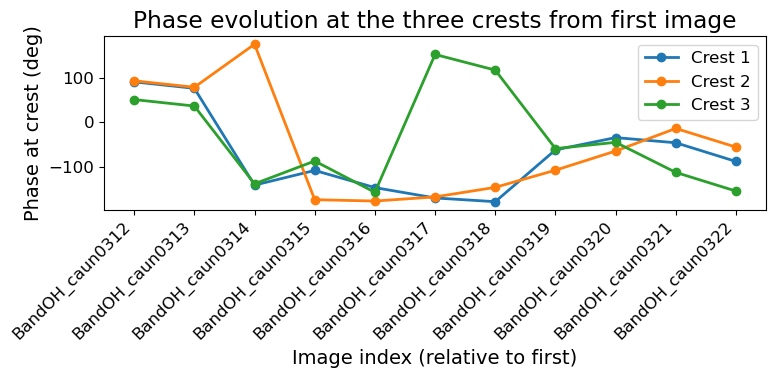

In [34]:
# %%
# Full TIFF -> ROI -> background removal -> wavelet clusters (batch version,
# with crest markers + ridge line + phase panel)
#
# For each TIFF in TIFF_DIR, this script:
#   - Runs the same pipeline as before
#   - Applies band-pass and angle filters to the wavelet decomposition
#       *before* cluster identification
#   - Identifies clusters on the filtered decomposition
#   - Reconstructs each selected cluster (here: strongest only)
#   - Saves a single figure with one row per cluster:
#         LEFT:   background (remaining_tapered_clean, centered)
#         MIDDLE: background + cluster reconstruction overlay
#                 + first three crests marked and numbered
#                 + ridge line (skeleton) along the bright band of the wave
#         RIGHT:  geometric phase (deg) constructed from λ, θ,
#                 wrapped and shifted so the ridge is ≈ +90°,
#                 using a cyclic colormap ("twilight").
#
# Overlay figures are saved as:
#   OVERLAY_DIR / "<tiff_stem>_overlay_clusters_crests_phase.png"
#
# Skeletons are saved as:
#   OVERLAY_DIR / "skeletons" / "<tiff_stem>_cluster<id>_ridge_mask.npy"
#   OVERLAY_DIR / "skeletons" / "<tiff_stem>_cluster<id>_ridge.csv"
#
# Additionally:
#   - Uses the three crests (local maxima) from the FIRST TIFF (cluster 0)
#   - For each TIFF, samples the phase at those 3 pixels
#   - At the end, plots phase vs image index for the 3 crests.

from __future__ import annotations
from typing import Tuple, Optional, List

from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter, maximum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------

# Folder with input TIFFs
TIFF_DIR = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th713"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests_phase" will be created inside TIFF_DIR
OVERLAY_DIR: Optional[str] = None

# ROI (pixel slices) for analysis. Set to None to use full image.
X_SLICE: Optional[slice] = slice(0, 100)   # slice(12, 308)
Y_SLICE: Optional[slice] = slice(100, 200) # slice(18, 248)

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.1           # thr for identify_cluster2d

# Band-pass filter on effective wavelength λ (km)
# λ is computed from λx, λy via: 1/λ² = 1/λx² + 1/λy²
ENABLE_BANDPASS = True      # set True to enable band-pass
BANDPASS_LMIN_KM = 8.0      # lower bound in km
BANDPASS_LMAX_KM = 16.0     # upper bound in km

# Angle filter on wave-vector direction (degrees)
# Angle is defined from kx, ky via atan2(ky, kx), then wrapped to [0, 180)
ENABLE_ANGLE_FILTER = True   # set True to enable angle filter
ANGLE_MIN_DEG = 10.0         # lower bound in degrees
ANGLE_MAX_DEG = 80.0         # upper bound in degrees

# Cluster plotting controls
MAX_CLUSTERS = 1             # maximum number of clusters to show per TIFF

# Crest detection parameters
CREST_NEIGHBORHOOD = 7       # neighborhood size for local maxima (pixels)
CREST_MIN_RELAMP = 0.2       # only accept maxima with amp >= this * (max amp of cluster)
CRESTS_PER_CLUSTER = 3       # "first three crests"

# Plot controls
SHOW_FIGS = False            # True = show all plots for each file (slower)
SAVE_OVERLAY = True          # Save the overlay figure (this is the main batch product)

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff(
    path: str,
) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(
    Z: np.ndarray,
    size: int = 3,
    k: float = 5.0,
) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    Parameters
    ----------
    Z : 2D array
    size : int
        Window size for local median (3, 5, ...)
    k : float
        Threshold in units of local MAD (~sigma). Larger = more tolerant.

    Returns
    -------
    2D array, same shape as Z
    """
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      interior stays ~1
      transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Helpers for λ and angle
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength λ (km) and angle θ (deg) for all (s, t).

    λ is from λx, λy via: 1/λ² = 1/λx² + 1/λy²
    θ is from kx, ky via atan2(ky, kx), wrapped to [0, 180).
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    # Effective wavelength
    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / (lamx**2), 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / (lamy**2), 0.0)
        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        # Wavevector components
        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)  # [0, 180)

    return lam_eff, theta_deg


def compute_cluster_lambda_and_angle(
    cwt: dict,
    idx_s: int,
    idx_t: int,
) -> Tuple[float, float]:
    """
    Convenience for a single cluster (for logging/title).
    """
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    lam = float(lam_eff[idx_s, idx_t])
    theta = float(theta_deg[idx_s, idx_t])
    return lam, theta


# --------------------------
# Crest detection
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 3,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    """
    Find up to `num` strongest local crests (positive local maxima) in Z.

    Parameters
    ----------
    Z : 2D array (cluster reconstruction, centered)
    num : int
        Maximum number of crests to return
    neighborhood : int
        Size of neighborhood for local maxima (square window)
    min_rel_amp : float
        Only accept maxima with value >= min_rel_amp * max(Z)

    Returns
    -------
    List of (iy, ix, value) sorted by descending value
    """
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        # No positive signal: just return empty
        return []

    neighborhood = max(int(neighborhood), 1)

    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)
    if ys.size == 0:
        # Fallback: just pick the global max as one "crest"
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []
    for idx in order[:num]:
        iy = int(ys[idx])
        ix = int(xs[idx])
        crests.append((iy, ix, float(vals[idx])))

    return crests


# --------------------------
# Ridge line (skeleton) along the bright band
# --------------------------
def compute_ridge_mask(
    Z: np.ndarray,
    level_frac: float = 0.6,
) -> np.ndarray:
    """
    Compute a 1-pixel-wide ridge mask for the dominant bright band in Z.

    Steps:
      - threshold at level_frac * max(Z)
      - keep the connected component that contains the global max
      - skeletonize that component (thin it to 1-pixel wide)

    Returns
      ridge_mask: bool array, same shape as Z
    """
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level
    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    # Label connected components
    labels, num = ndimage.label(mask)
    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    # Find which component contains the global maximum
    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]
    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak

    # Skeletonize to get a 1-pixel-wide ridge
    ridge = morphology.skeletonize(peak_comp)

    return ridge


# --------------------------
# Single-file pipeline
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
    crest_iy: Optional[np.ndarray] = None,
    crest_ix: Optional[np.ndarray] = None,
    init_crests_from_this_file: bool = False,
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Run the full pipeline on a single TIFF and optionally save the overlay figure.

    Returns
    -------
    phases_on_crests : 1D array of phase (deg) at first-image crest pixels for this TIFF
                       (None if crests not defined or no cluster)
    crest_iy, crest_ix : 1D arrays of crest indices (row, col) from the first TIFF
    """
    print(f"\n=== Processing {tiff_path.name} ===")
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    # Compute mean/std once on the full image, use ±0.5σ
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean={center:.2f}, sigma={sigma:.2f}, clip=[{lo:.2f}, {hi:.2f}]")

    # Full preview (optional)
    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        vals_full = preview.ravel()
        p5f, p50f, p95f = np.nanpercentile(vals_full, [5, 50, 95])
        print(f"[Full] Percentiles 5/50/95 (clipped): {p5f:.2f} / {p50f:.2f} / {p95f:.2f}")

        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        # ROI rectangle
        ysl_full = Y_SLICE if Y_SLICE is not None else slice(0, ny_full)
        xsl_full = X_SLICE if X_SLICE is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI
    ysl = Y_SLICE if Y_SLICE is not None else slice(None, None)
    xsl = X_SLICE if X_SLICE is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flipped for display

    print(f"[ROI] shape: {raw.shape}")

    # Clip ROI
    proc0 = np.clip(raw, lo, hi)

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel (if needed)
    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # Optional background figure
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper (spikes removed)"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical",
                                  fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")

        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # --------------------------
    # Apply band-pass & angle filters to decomposition BEFORE clustering
    # --------------------------
    decomposition = cwt["decomposition"]
    ns, nt, nx_cwt, ny_cwt = decomposition.shape

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_band = (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )
        mask_keep &= mask_band

    if ENABLE_ANGLE_FILTER:
        mask_angle = (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )
        mask_keep &= mask_angle

    n_total_modes = lam_eff.size
    n_keep_modes = int(mask_keep.sum())
    print(f"[Filter] Modes kept: {n_keep_modes}/{n_total_modes}")

    # Broadcast mask over spatial dims and zero-out disallowed modes
    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # --------------------------
    # Identify clusters on filtered decomposition
    # --------------------------
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    # Keep a copy of the filtered decomposition BEFORE zeroing other clusters
    orig_decomp = decomposition.copy()

    # Background for overlays: tapered remaining field (centered, spikes removed), grayscale
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # ---------- Clusters ----------
    n_clusters = len(amps) if amps is not None else 0
    print(f"[Clusters] n_clusters (after filters) = {n_clusters}")

    # Folder for skeleton outputs (shared for all clusters of this TIFF)
    skeleton_dir = overlay_dir / "skeletons"
    skeleton_dir.mkdir(parents=True, exist_ok=True)

    # For crest tracking
    crest_iy_out = crest_iy
    crest_ix_out = crest_ix
    phases_on_crests = None

    if n_clusters == 0:
        print("[Clusters] No cluster found after filters; nothing to overlay.")
        fig_empty, ax = plt.subplots(figsize=(6, 4))
        ax.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")
        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
            fig_empty.savefig(out_path, dpi=200)
            print(f"[Save] Overlay saved to: {out_path}")

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)

        # No clusters, no phase info
        return None, crest_iy_out, crest_ix_out

    # Sort clusters by amplitude (descending) and limit to MAX_CLUSTERS
    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    # --------------------------
    # Figure: one row per cluster, 3 columns:
    #   col 0: background only
    #   col 1: background + overlay (cluster, crests, ridge)
    #   col 2: phase (deg) constructed from λ, θ (ridge ~ +90°)
    # --------------------------
    fig, axes = plt.subplots(
        n_show, 3,
        figsize=(15, 4 * n_show),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)  # ensures axes[j, 0] works even if n_show=1

    # Loop over clusters
    for j in range(n_show):
        kcl = int(order[j])
        ax_bg = axes[j, 0]
        ax_ov = axes[j, 1]
        ax_ph = axes[j, 2]   # phase subplot

        # -------------------------
        # LEFT PANEL: background only
        # -------------------------
        ax_bg.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )
        ax_bg.set_title("Background (remaining_tapered_clean)")
        ax_bg.set_aspect("equal", adjustable="box")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")

        # -------------------------
        # MIDDLE PANEL: overlay (background + reconstruction)
        # -------------------------
        # Reconstruct this cluster
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_centered = rec.T - np.median(rec)  # back to (ny, nx)
        ny_img, nx_img = rec_centered.shape

        # Background underlay
        ax_ov.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        # Overlay cluster reconstruction
        cl_vmin, cl_vmax = -0.6, 0.6
        ax_ov.pcolormesh(
            x1d,
            y1d,
            rec_centered,
            shading="auto",
            cmap="RdBu_r",
            vmin=cl_vmin,
            vmax=cl_vmax,
            alpha=0.6,
        )

        # -------------------------
        # Ridge line of local maxima ("line along the peak")
        # -------------------------
        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)

        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)

            # Sort roughly left-to-right for a cleaner line
            order_r = np.argsort(xs_ridge)
            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)

            # Convert to display coordinates (y is flipped)
            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted

            ax_ov.plot(
                x_disp_r,
                y_disp_r,
                linewidth=1.5,
                color="yellow",
            )

            # -------------------------
            # SAVE SKELETONS
            # -------------------------
            # 1) Save skeleton mask (ROI coordinates, not flipped)
            skel_npy = skeleton_dir / f"{tiff_path.stem}_cluster{kcl}_ridge_mask.npy"
            np.save(skel_npy, ridge_mask)

            # 2) Save ridge coordinates as CSV
            coords = np.column_stack([xs_sorted, ys_sorted, x_disp_r, y_disp_r])
            skel_csv = skeleton_dir / f"{tiff_path.stem}_cluster{kcl}_ridge.csv"
            np.savetxt(
                skel_csv,
                coords,
                delimiter=",",
                fmt="%.3f",
                header="ix,iy,x_disp,y_disp",
                comments="",
            )
            print(f"[Skeleton] Saved ridge mask to {skel_npy}")
            print(f"[Skeleton] Saved ridge coords to {skel_csv}")
        else:
            print(f"[Skeleton] No ridge found for cluster {kcl}")

        # Cluster wavelength and angle (for title & phase)
        s_idx = int(idxs[kcl][0])
        t_idx = int(idxs[kcl][1])
        lam_best, theta_best = compute_cluster_lambda_and_angle(cwt, s_idx, t_idx)

        title_str = (
            f"Cluster {j+1} (id={kcl})\n"
            rf"$\lambda$={_fmt(lam_best)}, $\theta$={theta_best:.1f}°"
        )
        ax_ov.set_title(title_str)
        ax_ov.set_aspect("equal", adjustable="box")

        # -------------------------
        # PHASE PANEL: geometric phase built from λ, θ
        # Shift so ridge is ≈ +90°, wrap cyclically.
        # -------------------------
        # Grid of array indices
        iy_grid, ix_grid = np.mgrid[0:ny_img, 0:nx_img]

        # Physical coords in km
        x_km = ix_grid.astype(float) * DX
        y_km = iy_grid.astype(float) * DY

        theta_rad = np.deg2rad(theta_best)

        # Distance along propagation direction (k-hat) in km
        s_km = x_km * np.cos(theta_rad) + y_km * np.sin(theta_rad)

        # Geometric phase φ(x,y) in radians
        phi = 2.0 * np.pi * s_km / lam_best

        # Shift so that the ridge pixels sit near +90° (π/2 rad)
        if np.any(ridge_mask):
            phi_ridge = np.median(phi[ridge_mask])
            phi = phi - phi_ridge + (np.pi / 2.0)

        # Wrap to [-π, π] (cyclic) and convert to degrees
        phi_wrapped = np.angle(np.exp(1j * phi))  # radians, cyclic
        phase_geom_deg = np.degrees(phi_wrapped)  # [-180, 180] deg

        # Cluster mask in image plane: any (s,t) assigned to this cluster
        mask_cluster_xy = np.any(iwave == kcl, axis=(0, 1))   # (nx, ny)
        mask_cluster_img = mask_cluster_xy.T                  # (ny, nx)

        # Only show phase where this cluster lives
        phase_cluster = np.where(mask_cluster_img, phase_geom_deg, np.nan)

        im_ph = ax_ph.pcolormesh(
            x1d,
            y1d,
            phase_cluster,
            shading="auto",
            cmap="twilight",     # cyclic colormap
            vmin=-180.0,
            vmax=180.0,
        )
        ax_ph.set_title("Phase (deg, ridge ≈ +90°)")
        ax_ph.set_aspect("equal", adjustable="box")
        ax_ph.set_xlabel("x (pixels)")
        ax_ph.set_ylabel("y (pixels)")

        cbar_ph = fig.colorbar(
            im_ph,
            ax=ax_ph,
            fraction=0.046,
            pad=0.04,
        )
        cbar_ph.set_label("Phase (deg)")

        # -------------------------
        # Mark crests on overlay
        # -------------------------
        crests = find_top_crests(
            rec_centered,
            num=CRESTS_PER_CLUSTER,
            neighborhood=CREST_NEIGHBORHOOD,
            min_rel_amp=CREST_MIN_RELAMP,
        )

        for n, (iy, ix, val) in enumerate(crests, start=1):
            # Convert array index (iy, ix) to display coordinates:
            x_disp = float(ix)
            y_disp = float(ny_img - 1 - iy)

            ax_ov.plot(
                x_disp,
                y_disp,
                marker="o",
                markersize=6,
                markerfacecolor="none",
                markeredgecolor="yellow",
                markeredgewidth=1.5,
            )
            ax_ov.text(
                x_disp + 1.0,
                y_disp + 1.0,
                f"{n}",
                color="yellow",
                fontsize=10,
                weight="bold",
            )

        ax_ov.set_xlabel("x (pixels)")
        ax_ov.set_ylabel("y (pixels)")

        print(
            f"[Cluster {kcl}] amp={amps[kcl]:.3f}, "
            f"lam={_fmt(lam_best)}, theta={theta_best:.1f}°, "
            f"crests_found={len(crests)}"
        )

        # -------------------------
        # Crest tracking for first cluster only (j == 0)
        # -------------------------
        if j == 0:
            # For the FIRST file: store the 3 crest positions from that reconstruction
            if init_crests_from_this_file and crest_iy_out is None and crest_ix_out is None:
                if len(crests) > 0:
                    # Take up to CRESTS_PER_CLUSTER, already sorted by amplitude
                    n_use = min(len(crests), CRESTS_PER_CLUSTER)
                    crest_iy_out = np.array([crests[m][0] for m in range(n_use)], dtype=int)
                    crest_ix_out = np.array([crests[m][1] for m in range(n_use)], dtype=int)
                    print(f"[Crest tracking] Stored {len(crest_iy_out)} crests from first image.")
                else:
                    print("[Crest tracking] No crests found in first image.")

            # For every file: if crest indices exist, sample phase there
            if crest_iy_out is not None and crest_ix_out is not None:
                if (crest_iy_out.max() < ny_img) and (crest_ix_out.max() < nx_img):
                    phases_on_crests = phase_geom_deg[crest_iy_out, crest_ix_out]
                else:
                    print("[Crest tracking] Stored crest indices out of bounds; skipping phase sampling.")
                    phases_on_crests = None

    fig.suptitle(f"{tiff_path.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # Save overlay figure
    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
        fig.savefig(out_path, dpi=200)
        print(f"[Save] Overlay saved to: {out_path}")

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)

    return phases_on_crests, crest_iy_out, crest_ix_out


# --------------------------
# Batch driver
# --------------------------
def run_batch():
    tiff_dir = Path(TIFF_DIR)
    if OVERLAY_DIR is not None:
        overlay_dir = Path(OVERLAY_DIR)
    else:
        overlay_dir = tiff_dir / "overlays_crests_phase"

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))
    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")
    print(f"Overlay output directory: {overlay_dir}")

    crest_iy = None
    crest_ix = None
    crest_phase_series: List[np.ndarray] = []
    file_labels: List[str] = []

    for i, tiff_path in enumerate(files):
        phases_on_crests, crest_iy, crest_ix = run_pipeline_for_file(
            tiff_path=tiff_path,
            overlay_dir=overlay_dir,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
            crest_iy=crest_iy,
            crest_ix=crest_ix,
            init_crests_from_this_file=(i == 0),
        )

        if phases_on_crests is not None:
            crest_phase_series.append(phases_on_crests)
            file_labels.append(tiff_path.stem)

    # --------------------------
    # Plot phase evolution at the three crests from first image
    # --------------------------
    if crest_phase_series:
        phase_arr = np.vstack(crest_phase_series)  # (n_files_used, n_crests)
        n_files_used, n_crests = phase_arr.shape
        frames = np.arange(n_files_used)

        fig, ax = plt.subplots(figsize=(8, 4))

        # Plot each crest as its own line
        for p in range(n_crests):
            ax.plot(frames, phase_arr[:, p], marker="o", linewidth=2,
                    label=f"Crest {p+1}")

        ax.set_xlabel("Image index (relative to first)")
        ax.set_ylabel("Phase at crest (deg)")
        ax.set_title("Phase evolution at the three crests from first image")
        ax.set_xticks(frames)
        ax.set_xticklabels(file_labels, rotation=45, ha="right")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("[Crest tracking] No crest phase data collected; skipping final phase plot.")


if __name__ == "__main__":
    run_batch()


## Analyze phase

In [19]:
# analyze_ridge_motion_skip_bad_line_shift.py
#
# Read ridge skeletons saved by the batch CWT script and compute
# how much each ridge (treated as a straight line) shifts in the
# direction perpendicular to that line between successive GOOD frames.
#
# Steps:
#   1) Load all skeleton CSVs for one cluster.
#   2) Filter out bad ridges (manual exclude + quality checks).
#   3) Sort remaining "good" frames by filename.
#   4) For each consecutive good pair:
#        - fit a straight line to ridge 1
#        - build its unit normal vector
#        - project both ridges onto that normal
#        - compute the mean shift of line 2 relative to line 1
#   5) Plot all good skeletons together in ROI pixel coordinates.
#
# Outputs:
#   - printed summary to stdout
#   - CSV file "ridge_line_shift_cluster<id>_skip_bad.csv"
#   - PNG  "ridge_skeletons_cluster<id>_skip_bad.png" in SKELETON_DIR

from __future__ import annotations
from pathlib import Path
from typing import Tuple, List

import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# User parameters
# --------------------------

# Folder where the skeleton CSVs live
SKELETON_DIR = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\overlays_crests\skeletons"

# Cluster id to analyze (default: 0, because MAX_CLUSTERS = 1)
CLUSTER_ID = 0

# Pixel size in km (assumed same in x and y)
PIXEL_SIZE_KM = 0.623

# Manual bad-frame handling
# Put TIFF stems here to skip them entirely.
EXCLUDE_STEMS: set[str] = set({"BandOH_caun0126", "BandOH_caun0127"})

# Automatic quality thresholds
MIN_POINTS = 10      # minimum number of ridge points to consider it valid
MIN_XSPAN = 5.0      # minimum x-extent (pixels) for a ridge to be valid


# --------------------------
# Helpers
# --------------------------

def load_ridge_coords(csv_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load ridge coordinates from a CSV file.

    CSV format (from previous script):
        header: ix,iy,x_disp,y_disp
        data:   float, float, float, float

    Returns
    -------
    ix_sorted, iy_sorted : 1D arrays
        Ridge points sorted by ix (left -> right) in ROI pixel indices.
    """
    arr = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]  # handle single-point skeleton gracefully

    ix = arr[:, 0]
    iy = arr[:, 1]

    order = np.argsort(ix)
    ix_sorted = ix[order]
    iy_sorted = iy[order]

    return ix_sorted, iy_sorted


def is_good_ridge(ix: np.ndarray, iy: np.ndarray, stem: str) -> bool:
    """
    Decide whether a ridge is usable.

    Criteria:
      - not manually excluded
      - at least MIN_POINTS points
      - x-span >= MIN_XSPAN
    """
    if stem in EXCLUDE_STEMS:
        print(f"[Skip] {stem}: in EXCLUDE_STEMS")
        return False

    if ix.size < MIN_POINTS:
        print(f"[Skip] {stem}: too few ridge points ({ix.size} < {MIN_POINTS})")
        return False

    xspan = float(ix.max() - ix.min()) if ix.size > 0 else 0.0
    if xspan < MIN_XSPAN:
        print(f"[Skip] {stem}: x-span too small ({xspan:.2f} px < {MIN_XSPAN} px)")
        return False

    return True


def fit_line_and_normal(ix: np.ndarray, iy: np.ndarray) -> Tuple[float, float, np.ndarray]:
    """
    Fit a straight line y = m*x + c to ridge points and compute a unit normal.

    Parameters
    ----------
    ix, iy : 1D arrays of ridge pixel coordinates.

    Returns
    -------
    m    : slope of the fitted line
    c    : intercept of the fitted line
    nhat : (2,) unit normal vector (nx, ny) pointing perpendicular to the line
    """
    ix = np.asarray(ix, float)
    iy = np.asarray(iy, float)

    if ix.size < 2:
        # Degenerate: assume horizontal line
        m = 0.0
        c = float(iy.mean()) if iy.size > 0 else 0.0
        # For y = const, a normal is vertical (0, 1)
        nhat = np.array([0.0, 1.0], dtype=float)
        return m, c, nhat

    # Least squares line fit
    m, c = np.polyfit(ix, iy, 1)

    # For y = m x + c, one normal vector is (m, -1)
    n = np.array([m, -1.0], dtype=float)
    norm_n = float(np.hypot(n[0], n[1]))
    if norm_n == 0.0:
        # Fallback: vertical normal
        nhat = np.array([0.0, 1.0], dtype=float)
    else:
        nhat = n / norm_n

    return float(m), float(c), nhat


def line_shift_between_ridges(
    ix1: np.ndarray,
    iy1: np.ndarray,
    ix2: np.ndarray,
    iy2: np.ndarray,
) -> Tuple[float, float, float, float]:
    """
    Treat each ridge as a straight line and compute how much line 2 is shifted
    relative to line 1 along the normal direction of line 1.

    Steps:
      - Fit a line to ridge 1: y = m1 x + c1
      - Get unit normal n_hat to that line
      - Compute mean projection of ridge 1 points onto n_hat
      - Compute mean projection of ridge 2 points onto n_hat
      - Shift = proj2_mean - proj1_mean

    Parameters
    ----------
    ix1, iy1 : ridge 1 coordinates
    ix2, iy2 : ridge 2 coordinates

    Returns
    -------
    shift_px : signed shift along the normal (pixels)
    shift_km : same in km
    m1       : slope of line 1
    c1       : intercept of line 1
    """
    ix1 = np.asarray(ix1, float)
    iy1 = np.asarray(iy1, float)
    ix2 = np.asarray(ix2, float)
    iy2 = np.asarray(iy2, float)

    # Fit line and normal for ridge 1
    m1, c1, n_hat = fit_line_and_normal(ix1, iy1)  # n_hat shape (2,)

    # Build coordinates
    p1 = np.stack([ix1, iy1], axis=-1)  # (N1, 2)
    p2 = np.stack([ix2, iy2], axis=-1)  # (N2, 2)

    # Projections onto n_hat
    proj1 = p1 @ n_hat  # dot products, shape (N1,)
    proj2 = p2 @ n_hat  # shape (N2,)

    proj1_mean = float(np.nanmean(proj1))
    proj2_mean = float(np.nanmean(proj2))

    shift_px = proj2_mean - proj1_mean
    shift_km = shift_px * PIXEL_SIZE_KM

    return shift_px, shift_km, m1, c1


def plot_all_skeletons(good_frames: List[dict], out_path: Path) -> None:
    """
    Plot all good skeletons in ROI pixel coordinates on one figure.

    Uses ix, iy (ROI indices). y-axis is inverted so it matches image convention.
    """
    if not good_frames:
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    cmap = plt.get_cmap("viridis")
    n = len(good_frames)

    for i, gf in enumerate(good_frames):
        ix = gf["ix"]
        iy = gf["iy"]
        color = cmap(i / max(n - 1, 1))
        label = gf["stem"] if n <= 15 else None  # avoid giant legend

        ax.plot(ix, iy, "-", color=color, alpha=0.8, label=label)

    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(f"All good skeletons – cluster {CLUSTER_ID}")
    ax.invert_yaxis()  # y increasing downward like image coordinates
    ax.set_aspect("equal", adjustable="box")

    if n <= 15:
        ax.legend(fontsize=8, loc="best")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

    print(f"[Plot] All skeletons figure saved to: {out_path}")


# --------------------------
# Main analysis
# --------------------------

def main():
    skeleton_dir = Path(SKELETON_DIR)

    if not skeleton_dir.is_dir():
        print(f"Skeleton directory does not exist: {skeleton_dir}")
        return

    pattern = f"*_cluster{CLUSTER_ID}_ridge.csv"
    files: List[Path] = sorted(skeleton_dir.glob(pattern))

    if not files:
        print(f"No skeleton files matching {pattern} in {skeleton_dir}")
        return

    print(f"Found {len(files)} skeleton files for cluster {CLUSTER_ID} in {skeleton_dir}")

    # First pass: build list of good frames only
    good_frames = []  # list of dicts: {"stem", "path", "ix", "iy"}

    for f in files:
        stem = f.name.replace(f"_cluster{CLUSTER_ID}_ridge.csv", "")
        ix, iy = load_ridge_coords(f)

        if is_good_ridge(ix, iy, stem):
            good_frames.append({
                "stem": stem,
                "path": f,
                "ix": ix,
                "iy": iy,
            })

    if len(good_frames) < 2:
        print(f"Only {len(good_frames)} good frames after filtering. Need at least 2.")
        return

    print(f"Using {len(good_frames)} good frames (bad frames skipped).")

    # Plot all skeletons together
    out_plot = skeleton_dir / f"ridge_skeletons_cluster{CLUSTER_ID}_skip_bad.png"
    plot_all_skeletons(good_frames, out_plot)

    # Second pass: compare consecutive good frames as lines
    records = []
    header = [
        "tiff1", "tiff2",
        "shift_px", "shift_km",
        "slope_m1", "intercept_c1",
    ]

    for i in range(len(good_frames) - 1):
        g1 = good_frames[i]
        g2 = good_frames[i + 1]

        stem1 = g1["stem"]
        stem2 = g2["stem"]

        ix1, iy1 = g1["ix"], g1["iy"]
        ix2, iy2 = g2["ix"], g2["iy"]

        shift_px, shift_km, m1, c1 = line_shift_between_ridges(ix1, iy1, ix2, iy2)

        print(
            f"{stem1} -> {stem2}: "
            f"shift = {shift_px:.3f} px ({shift_km:.3f} km), "
            f"slope m1 = {m1:.4f}, intercept c1 = {c1:.2f}"
        )

        records.append([
            stem1, stem2,
            shift_px, shift_km,
            m1, c1,
        ])

    # Save summary CSV
    out_csv = skeleton_dir / f"ridge_line_shift_cluster{CLUSTER_ID}_skip_bad.csv"
    with out_csv.open("w", encoding="utf-8") as f:
        f.write(",".join(header) + "\n")
        for row in records:
            # tiff1, tiff2 are strings; others are floats
            line = f"{row[0]},{row[1]}"
            for val in row[2:]:
                line += f",{val:.6f}"
            f.write(line + "\n")

    print(f"\nSummary saved to: {out_csv}")
    print(f"Pairs used: {len(records)} (between good frames only)")


if __name__ == "__main__":
    main()


Found 10 skeleton files for cluster 0 in C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\overlays_crests\skeletons
[Skip] BandOH_caun0126: in EXCLUDE_STEMS
[Skip] BandOH_caun0127: in EXCLUDE_STEMS
Using 8 good frames (bad frames skipped).
[Plot] All skeletons figure saved to: C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527\overlays_crests\skeletons\ridge_skeletons_cluster0_skip_bad.png
BandOH_caun0121 -> BandOH_caun0122: shift = -3.083 px (-1.921 km), slope m1 = 0.3173, intercept c1 = 34.72
BandOH_caun0122 -> BandOH_caun0123: shift = -3.398 px (-2.117 km), slope m1 = 0.2680, intercept c1 = 40.29
BandOH_caun0123 -> BandOH_caun0124: shift = -3.353 px (-2.089 km), slope m1 = 0.2755, intercept c1 = 43.50
BandOH_caun0124 -> BandOH_caun0125: shift = -3.524 px (-2.196 km), slope m1 = 0.3130, intercept c1 = 45.36
BandOH_caun0125 -> BandOH_caun0128: shift = -10.354 px (-6.451 km), slope m1 = 0.3176, intercept c1 = 48.83
BandOH_caun0128 -> BandOH_caun0129: shift = -3.893 px